In [1]:
import numpy as np
import pylidc as pl
import matplotlib as plt
import matplotlib.pyplot as plt
import matplotlib.animation as manim
from sqlalchemy import and_
from tabulate import tabulate
from pylidc.utils import consensus
from skimage.measure import find_contours

# Scan Class

In [2]:
scans = pl.query(pl.Scan)
print(f"scans dtype: {type(scans)}")
print(f"num of scans: {scans.count()}")

scans dtype: <class 'sqlalchemy.orm.query.Query'>
num of scans: 1018


In [3]:
pid = 'LIDC-IDRI-0078'
scan = pl.query(pl.Scan).filter(pl.Scan.patient_id == pid).first()

## Eksplore LIDC-IDRI-0078

In [4]:
scan = scans.first()

data_scan = [
    ["study instance uid", str(scan.study_instance_uid), str(type(scan.study_instance_uid))],
    ["series instance uid", str(scan.series_instance_uid), str(type(scan.series_instance_uid))],
    ["patient id", str(scan.patient_id), str(type(scan.patient_id))],
    ["slice thickness", str(scan.slice_thickness), str(type(scan.slice_thickness))],
    ["slice zvals", str(scan.slice_zvals), str(type(scan.slice_zvals))],
    ["num of slices", str(len(scan.slice_zvals)), str(type(len(scan.slice_zvals)))],
    ["slice spacing", str(scan.slice_spacing), str(type(scan.slice_spacing))],
    ["pixel spacing", str(scan.pixel_spacing), str(type(scan.pixel_spacing))],
    ["contrast used", str(scan.contrast_used), str(type(scan.contrast_used))],
    ["is from initial", str(scan.is_from_initial), str(type(scan.is_from_initial))],
    ["annotations", str(scan.annotations), str(type(scan.annotations))],
    ["access an annotations object", str(scan.annotations[0]), str(type(scan.annotations[0]))],
    ["cluster annotations", str(scan.cluster_annotations()), str(type(scan.cluster_annotations()))]
]

print(tabulate(data_scan, headers=["Attribute", "Value", "Data Type"], tablefmt="grid"))

+------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------------------------------------------+
| Attribute                    | Value                                                                                                                                                                                                                                                                                                                                                                                    | Data Type                                             |
+==============================+================================

# Converting scan image values to NumPy array

In [5]:
vol = scan.to_volume()
print(f"shape [width, height, num_slices]: {vol.shape}")

Loading dicom files ... This may take a moment.
shape [width, height, num_slices]: (512, 512, 87)


## Eksplore Annotation dari Scan LIDC-IDRI-0078 

*   cluster 1 (node 1) =  [Annotation(id=2,scan_id=1), Annotation(id=6,scan_id=1), Annotation(id=10,scan_id=1), Annotation(id=13,scan_id=1)]
*   cluster 2 (node 2) = [Annotation(id=1,scan_id=1), Annotation(id=5,scan_id=1), Annotation(id=9,scan_id=1), Annotation(id=12,scan_id=1)]
*   cluster 3 (node 3) = [Annotation(id=8,scan_id=1)]
*   cluster 4 (node 4) = [Annotation(id=3,scan_id=1), Annotation(id=4,scan_id=1), Annotation(id=7,scan_id=1), Annotation(id=11,scan_id=1)]

meskipun Annotation(id=2,scan_id=1) dan Annotation(id=6,scan_id=1) sama-sama tercluster ke dalam node 1, masing-masing annotation tersebut memiliki nilai attribute yang berbeda

In [6]:
ann = next((a for a in scan.annotations if a.id == 2), None)
ann_data = [
    ["ann id", ann.id, "", type(ann.id)],
    ["subtlety", ann.subtlety, ann.Subtlety, type(ann.subtlety)],
    ["internalStructure", ann.internalStructure, ann.InternalStructure, type(ann.internalStructure)],
    ["calcification", ann.calcification, ann.Calcification, type(ann.calcification)],
    ["sphericity", ann.sphericity, ann.Sphericity, type(ann.sphericity)],
    ["margin", ann.margin, ann.Margin, type(ann.margin)],
    ["lobulation", ann.lobulation, ann.Lobulation, type(ann.lobulation)],
    ["spiculation", ann.spiculation, ann.Spiculation, type(ann.spiculation)],
    ["texture", ann.texture, ann.Texture, type(ann.texture)],
    ["malignancy", ann.malignancy, ann.Malignancy, type(ann.malignancy)],
    ["diameter", ann.diameter, "", type(ann.diameter)],
    ["surface_area", ann.surface_area, "", type(ann.surface_area)],
    ["volume", ann.volume, "", type(ann.volume)],
]

print(tabulate(ann_data, headers=["Attribute", "Value", "Meaning", "Data Type"], tablefmt="grid"))

+-------------------+---------+-----------------------+-------------------------+
| Attribute         |   Value | Meaning               | Data Type               |
+===================+=========+=======================+=========================+
| ann id            |    2    |                       | <class 'int'>           |
+-------------------+---------+-----------------------+-------------------------+
| subtlety          |    4    | Moderately Obvious    | <class 'int'>           |
+-------------------+---------+-----------------------+-------------------------+
| internalStructure |    1    | Soft Tissue           | <class 'int'>           |
+-------------------+---------+-----------------------+-------------------------+
| calcification     |    6    | Absent                | <class 'int'>           |
+-------------------+---------+-----------------------+-------------------------+
| sphericity        |    4    | Ovoid/Round           | <class 'int'>           |
+---------------

In [7]:
ann = next((a for a in scan.annotations if a.id == 6), None)
ann_data = [
    ["ann id", ann.id, "", type(ann.id)],
    ["subtlety", ann.subtlety, ann.Subtlety, type(ann.subtlety)],
    ["internalStructure", ann.internalStructure, ann.InternalStructure, type(ann.internalStructure)],
    ["calcification", ann.calcification, ann.Calcification, type(ann.calcification)],
    ["sphericity", ann.sphericity, ann.Sphericity, type(ann.sphericity)],
    ["margin", ann.margin, ann.Margin, type(ann.margin)],
    ["lobulation", ann.lobulation, ann.Lobulation, type(ann.lobulation)],
    ["spiculation", ann.spiculation, ann.Spiculation, type(ann.spiculation)],
    ["texture", ann.texture, ann.Texture, type(ann.texture)],
    ["malignancy", ann.malignancy, ann.Malignancy, type(ann.malignancy)],
    ["diameter", ann.diameter, "", type(ann.diameter)],
    ["surface_area", ann.surface_area, "", type(ann.surface_area)],
    ["volume", ann.volume, "", type(ann.volume)],
]

print(tabulate(ann_data, headers=["Attribute", "Value", "Meaning", "Data Type"], tablefmt="grid"))

+-------------------+-----------+-----------------------+-------------------------+
| Attribute         |     Value | Meaning               | Data Type               |
+===================+===========+=======================+=========================+
| ann id            |    6      |                       | <class 'int'>           |
+-------------------+-----------+-----------------------+-------------------------+
| subtlety          |    4      | Moderately Obvious    | <class 'int'>           |
+-------------------+-----------+-----------------------+-------------------------+
| internalStructure |    1      | Soft Tissue           | <class 'int'>           |
+-------------------+-----------+-----------------------+-------------------------+
| calcification     |    6      | Absent                | <class 'int'>           |
+-------------------+-----------+-----------------------+-------------------------+
| sphericity        |    4      | Ovoid/Round           | <class 'int'>     

# Annotation Class

In [8]:
anns = pl.query(pl.Annotation)
print(f"anns dtype: {type(anns)}")
print(f"num of anns: {anns.count()}")

anns dtype: <class 'sqlalchemy.orm.query.Query'>
num of anns: 6859


## Explore Annotation Instance Attribute

In [9]:
ann = pl.query(pl.Annotation).filter(pl.Annotation.id == 2, pl.Annotation.scan_id == 1).first()
print(ann.print_formatted_feature_table())


Feature              Meaning                    # 
-                    -                          - 
Subtlety           | Moderately Obvious       | 4 
Internalstructure  | Soft Tissue              | 1 
Calcification      | Absent                   | 6 
Sphericity         | Ovoid/Round              | 4 
Margin             | Near Sharp               | 4 
Lobulation         | No Lobulation            | 1 
Spiculation        | Nearly No Spiculation    | 2 
Texture            | Solid                    | 5 
Malignancy         | Indeterminate            | 3 
None


## Get Annotation Instance Contour (Coutour = Slice)

In [10]:
contours = ann.contours
print(f"num contours: {len(contours)}")

num contours: 6


In [11]:
rows = []

for c in contours:
    attrs = vars(c)
    
    rows.append([
        attrs.get("id"),
        attrs.get("annotation_id"),
        attrs.get("image_z_position"),
        len(attrs.get("coords").splitlines()) if attrs.get("coords") else 0,
        attrs.get("inclusion"),
        attrs.get("dicom_file_name"),
        type(c).__name__
    ])

print(tabulate(
    rows,
    headers=[
        "Contour ID",
        "Annotation ID",
        "Z Position",
        "Num Points",
        "Inclusion",
        "DICOM File",
        "Type"
    ],
    tablefmt="grid"
))

+--------------+-----------------+--------------+--------------+-------------+--------------+---------+
|   Contour ID |   Annotation ID |   Z Position |   Num Points | Inclusion   | DICOM File   | Type    |
+==============+=================+==============+==============+=============+==============+=========+
|            7 |               2 |       1487.5 |           56 | True        | 58.dcm       | Contour |
+--------------+-----------------+--------------+--------------+-------------+--------------+---------+
|            8 |               2 |       1484.5 |           71 | True        | 34.dcm       | Contour |
+--------------+-----------------+--------------+--------------+-------------+--------------+---------+
|            9 |               2 |       1481.5 |           82 | True        | 44.dcm       | Contour |
+--------------+-----------------+--------------+--------------+-------------+--------------+---------+
|           10 |               2 |       1478.5 |           84 |

## Get Annotation Mask

Masking tidak mencakup mencakup lebar dan tinggi hasil CT Scan

Masking memiliki ukurang lebar dan width berdasarkan bounding box nodule

In [12]:
mask = ann.boolean_mask()
print(mask.shape, mask.dtype)

(27, 28, 6) bool


## Get Annotation Bounding Box

In [13]:
bbox = ann.bbox()
print(bbox)

(slice(300, 327, None), slice(318, 346, None), slice(23, 29, None))


In [14]:
vol = ann.scan.to_volume()
print(vol[bbox].shape)

Loading dicom files ... This may take a moment.
(27, 28, 6)


In [15]:
print(ann.bbox_dims())

[16.9  17.55 15.  ]


## Annotation Visualization

Loading dicom files ... This may take a moment.


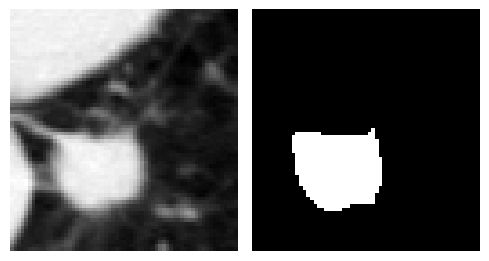

In [16]:
ann = pl.query(pl.Annotation).filter(pl.Annotation.id == 2, pl.Annotation.scan_id == 1).first()
vol = ann.scan.to_volume()

padding = [(30,10), (10,25), (0,0)]

mask = ann.boolean_mask(pad=padding)
bbox = ann.bbox(pad=padding)

fig,ax = plt.subplots(1,2,figsize=(5,3))

ax[0].imshow(vol[bbox][:,:,2], cmap=plt.cm.gray)
ax[0].axis('off')

ax[1].imshow(mask[:,:,2], cmap=plt.cm.gray)
ax[1].axis('off')

plt.tight_layout()
#plt.savefig("../images/mask_bbox.png", bbox_inches="tight")
plt.show()

cluster 1 (node 1) =  [Annotation(id=2,scan_id=1), Annotation(id=6,scan_id=1), Annotation(id=10,scan_id=1), Annotation(id=13,scan_id=1)]

Loading dicom files ... This may take a moment.


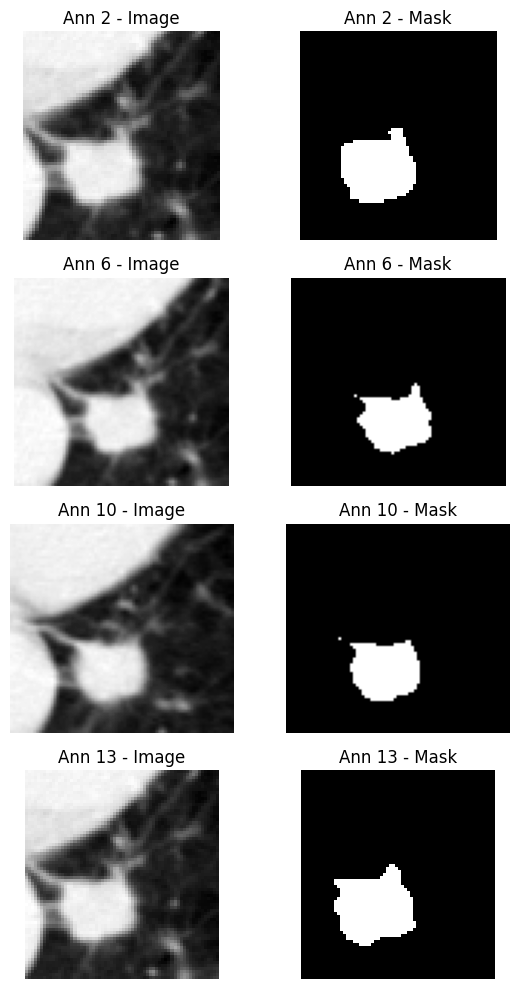

In [17]:


# ambil scan
scan = pl.query(pl.Scan).filter(pl.Scan.id == 1).first()

# ambil annotation dalam cluster 1
ann_ids = [2, 6, 10, 13]
annotations = [
    pl.query(pl.Annotation)
    .filter(and_(pl.Annotation.id == aid, pl.Annotation.scan_id == 1))
    .first()
    for aid in ann_ids
]

# volume scan
vol = scan.to_volume()

padding = [(30,10), (10,25), (0,0)]

fig, axes = plt.subplots(len(annotations), 2, figsize=(6, 10))

for i, ann in enumerate(annotations):
    mask = ann.boolean_mask(pad=padding)
    bbox = ann.bbox(pad=padding)

    # ambil slice tengah (lebih representatif daripada index 2)
    z_idx = mask.shape[2] // 2

    # image
    axes[i, 0].imshow(vol[bbox][:,:,z_idx], cmap='gray')
    axes[i, 0].set_title(f"Ann {ann.id} - Image")
    axes[i, 0].axis('off')

    # mask
    axes[i, 1].imshow(mask[:,:,z_idx], cmap='gray')
    axes[i, 1].set_title(f"Ann {ann.id} - Mask")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

# Annotation Consensus

Loading dicom files ... This may take a moment.


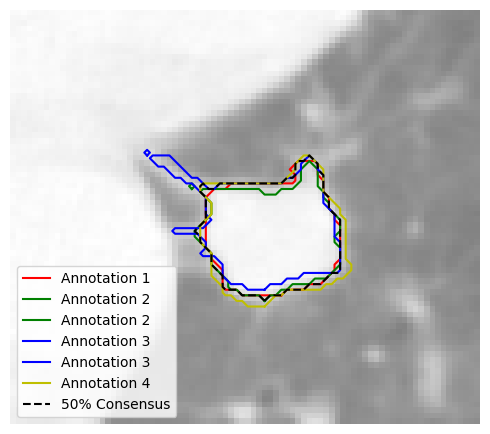

In [18]:
# Query for a scan, and convert it to an array volume.
scan = pl.query(pl.Scan).filter(pl.Scan.patient_id == 'LIDC-IDRI-0078').first()
vol = scan.to_volume()

# Cluster the annotations for the scan, and grab one.
nods = scan.cluster_annotations()
anns = nods[0]

# Perform a consensus consolidation and 50% agreement level.
# We pad the slices to add context for viewing.
cmask, cbbox, masks = consensus(anns, clevel=0.5, pad=[(20,20), (20,20), (0,0)])

# Get the central slice of the computed bounding box.
k = int(0.5*(cbbox[2].stop - cbbox[2].start))

# Set up the plot.
fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.imshow(vol[cbbox][:,:,k], cmap=plt.cm.gray, alpha=0.5) 

# Plot the annotation contours for the kth slice.
colors = ['r', 'g', 'b', 'y']
for j in range(len(masks)):
    for c in find_contours(masks[j][:,:,k].astype(float), 0.5):
        label = "Annotation %d" % (j+1)
        plt.plot(c[:,1], c[:,0], colors[j], label=label)

# Plot the 50% consensus contour for the kth slice.
for c in find_contours(cmask[:,:,k].astype(float), 0.5):
    plt.plot(c[:,1], c[:,0], '--k', label='50% Consensus')

ax.axis('off')
ax.legend()
plt.tight_layout()
#plt.savefig("../images/consensus.png", bbox_inches="tight")
plt.show()